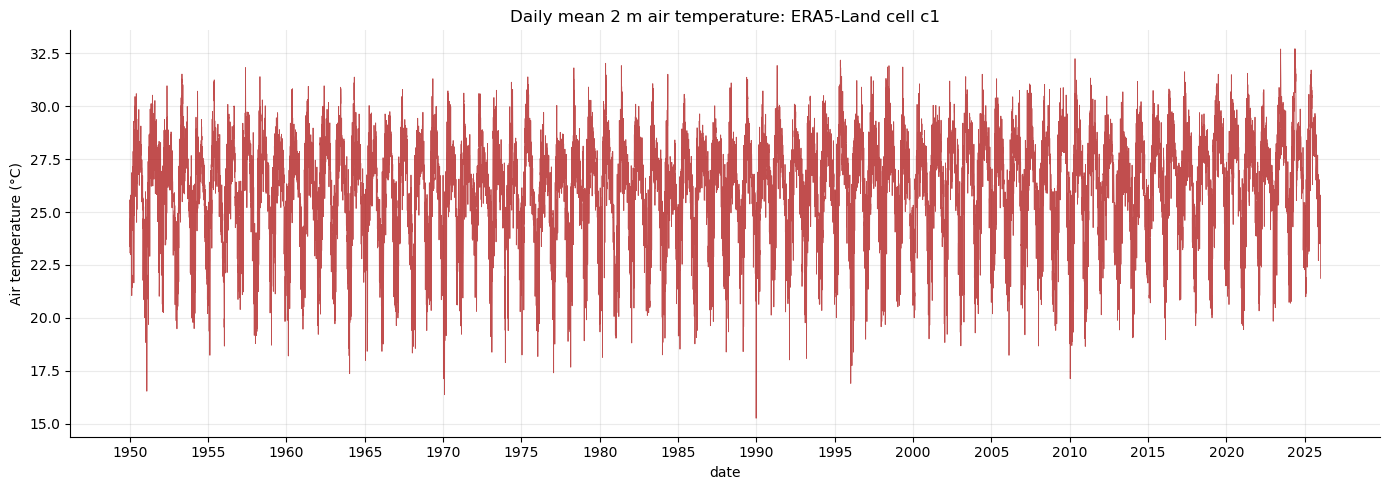

period: 1950-01-02 to 2025-12-31
observations: 27,758


In [2]:
# Daily mean 2 m air temperature for ERA5-Land cell c1
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_PATH = 'Sisal_ERA5Land_daily_all.csv'

weather = pd.read_csv(DATA_PATH, parse_dates=['date'])
temperature = (weather.set_index('date')['t2m_c_c1']
               .sort_index()
               .dropna())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(temperature.index, temperature.values,
        color='firebrick', lw=0.6, alpha=0.8)

ax.set_title('Daily mean 2 m air temperature: ERA5-Land cell c1')
ax.set_xlabel('date')
ax.set_ylabel('Air temperature (°C)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

print(f'period: {temperature.index.min():%Y-%m-%d} to {temperature.index.max():%Y-%m-%d}')
print(f'observations: {temperature.size:,}')


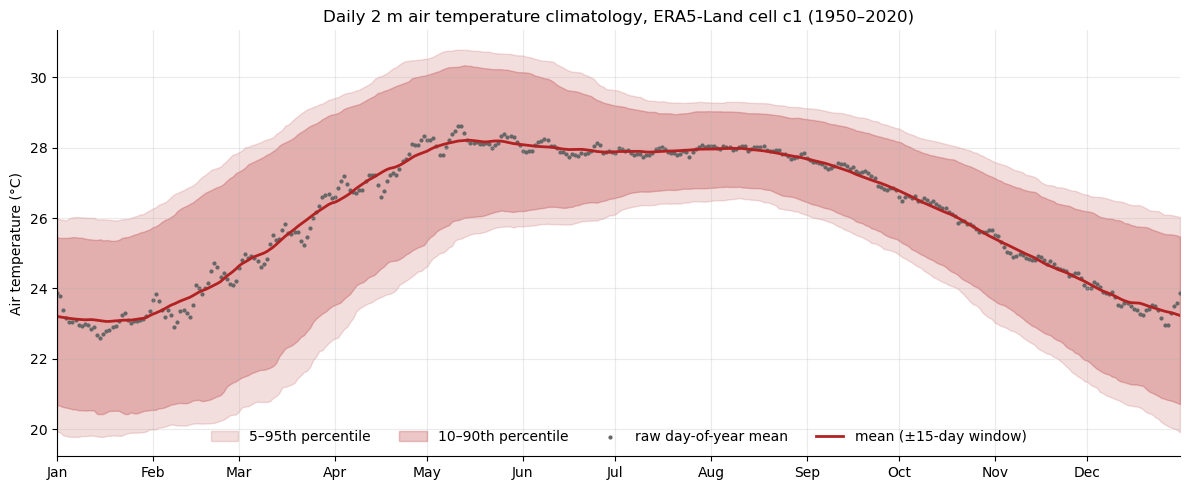

       mean   std    p10    p90
date                           
Jan   23.07  1.89  20.43  25.36
Feb   23.80  2.14  20.79  26.46
Mar   25.49  2.28  22.30  28.15
Apr   27.25  1.94  24.50  29.56
May   28.20  1.63  26.03  30.30
Jun   27.95  1.30  26.29  29.64
Jul   27.89  0.88  26.79  28.97
Aug   27.93  0.84  26.85  28.98
Sep   27.30  1.01  26.01  28.55
Oct   26.16  1.22  24.61  27.70
Nov   24.79  1.45  22.82  26.64
Dec   23.59  1.75  21.27  25.78


In [6]:
import numpy as np

# --- reference period (WMO standard); falls back to full record if shorter ---
REF_START, REF_END = '1950-01-01', '2020-12-31'
ref = temperature.loc[REF_START:REF_END]
n_years = ref.index.year.nunique()
if n_years < 30:
    print(f'WARNING: reference period has only {n_years} years '
          f'({ref.index.min():%Y}-{ref.index.max():%Y})')

# --- day of year on a 365-day calendar (drop Feb 29, shift leap-year Mar-Dec) ---
ref = ref[~((ref.index.month == 2) & (ref.index.day == 29))]
doy = (ref.index.dayofyear
       - ((ref.index.is_leap_year) & (ref.index.month > 2)).astype(int)).to_numpy()
vals = ref.to_numpy()

# --- pooled-window statistics, circular across Dec/Jan ---
HALF = 15
days = np.arange(1, 366)
rows = []
for d in days:
    dist = np.abs(doy - d)
    dist = np.minimum(dist, 365 - dist)
    v = vals[dist <= HALF]
    rows.append([v.mean(), v.std(ddof=1),
                 *np.percentile(v, [5, 10, 50, 90, 95]), v.size])
clim = pd.DataFrame(rows, index=pd.Index(days, name='doy'),
                    columns=['mean', 'std', 'p05', 'p10', 'p50', 'p90', 'p95', 'n'])

# raw (unpooled) day-of-year mean, for comparison
raw_mean = pd.Series(vals).groupby(doy).mean()

# --- plot on a dummy non-leap year so the axis shows months ---
x = pd.Timestamp('2001-01-01') + pd.to_timedelta(days - 1, unit='D')

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x, clim['p05'], clim['p95'], color='firebrick', alpha=0.15,
                label='5–95th percentile')
ax.fill_between(x, clim['p10'], clim['p90'], color='firebrick', alpha=0.25,
                label='10–90th percentile')
ax.scatter(x, raw_mean.values, s=4, color='0.4', label='raw day-of-year mean')
ax.plot(x, clim['mean'], color='firebrick', lw=2, label=f'mean (±{HALF}-day window)')

ax.set_title(f'Daily 2 m air temperature climatology, ERA5-Land cell c1 '
             f'({ref.index.min():%Y}–{ref.index.max():%Y})')
ax.set_ylabel('Air temperature (°C)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower center', ncol=4, frameon=False)
fig.tight_layout()
plt.show()

# --- monthly table ---
monthly = ref.groupby(ref.index.month).agg(
    mean='mean', std='std',
    p10=lambda s: s.quantile(0.10), p90=lambda s: s.quantile(0.90))
monthly.index = pd.to_datetime(monthly.index, format='%m').strftime('%b')
print(monthly.round(2))

clim.to_csv('clim_t2m_c1_doy.csv')   # reuse for anomalies next

In [7]:
import pandas as pd
import numpy as np

weather = (pd.read_csv(DATA_PATH, parse_dates=['date'])
             .sort_values('date')
             .reset_index(drop=True))
cells = ['c1', 'c2']
VARS = ['t2m_c', 't2m_min_c', 't2m_max_c', 'skin_t_c',
        'precip_mm', 'evap_mm', 'pot_evap_mm', 'evap_gap_mm']

# --- 1. completeness ---
full = pd.date_range(weather['date'].min(), weather['date'].max(), freq='D')
missing = full.difference(weather['date'])
print(f"period: {full[0]:%Y-%m-%d} to {full[-1]:%Y-%m-%d}")
print(f"rows: {len(weather):,} | expected: {len(full):,} | "
      f"missing dates: {len(missing)} | duplicate dates: {weather['date'].duplicated().sum()}")
if len(missing):
    print('first missing:', list(missing[:5].strftime('%Y-%m-%d')))
print('\nNaNs per column:')
print(weather.isna().sum()[lambda s: s > 0].to_string() or '  none')

# --- 2. value ranges ---
print('\nranges:')
print(weather.drop(columns='date').describe().T[['min', 'mean', 'max']].round(2))

# --- 3. physical consistency, per cell ---
for c in cells:
    t, tn, tx = (weather[f'{v}_{c}'] for v in ['t2m_c', 't2m_min_c', 't2m_max_c'])
    p, e, pe, gap = (weather[f'{v}_{c}'] for v in
                     ['precip_mm', 'evap_mm', 'pot_evap_mm', 'evap_gap_mm'])
    print(f'\n[{c}]')
    print(f"  Tmin > Tmean: {(tn > t).sum()} | Tmean > Tmax: {(t > tx).sum()} | "
          f"mean diurnal range: {(tx - tn).mean():.2f} °C")
    print(f"  negative precip days: {(p < 0).sum()}")
    print(f"  share of days > 0  -> evap: {(e > 0).mean():.2f}, pot_evap: {(pe > 0).mean():.2f}")
    # which formula reproduces evap_gap?
    candidates = {'pot_evap - evap': pe - e, 'evap - pot_evap': e - pe,
                  'precip - evap': p - e, 'precip + evap': p + e,
                  'pot_evap + evap': pe + e}
    for name, cand in candidates.items():
        print(f"  evap_gap vs {name:16s} max |diff| = {(gap - cand).abs().max():.4f}")

# --- 4. annual totals (years with >= 330 valid days only) ---
flux_cols = [f'{v}_{c}' for c in cells for v in ['precip_mm', 'evap_mm', 'pot_evap_mm']]
annual = (weather.set_index('date')[flux_cols]
                 .resample('YS').sum(min_count=330))
print('\nannual totals (mm/yr):')
print(annual.describe().T[['count', 'min', 'mean', 'max']].round(0))

# --- 5. c1 vs c2 ---
print('\nc1 vs c2:')
for v in VARS:
    a, b = weather[f'{v}_c1'], weather[f'{v}_c2']
    print(f"  {v:12s} mean(c1-c2) = {(a - b).mean():+7.2f} | r = {a.corr(b):.3f}")

period: 1950-01-02 to 2025-12-31
rows: 27,758 | expected: 27,758 | missing dates: 0 | duplicate dates: 0

NaNs per column:
Series([], )

ranges:
                  min   mean     max
t2m_c_c1        15.25  26.18   32.71
t2m_min_c_c1    14.01  23.30   28.52
t2m_max_c_c1    16.18  30.30   40.31
skin_t_c_c1     15.39  26.71   33.79
precip_mm_c1    -0.00   1.62  168.98
evap_mm_c1       0.03   1.59   18.10
pot_evap_mm_c1   2.97  26.68   68.30
evap_gap_mm_c1   0.03  25.09   68.03
t2m_c_c2        15.25  26.18   32.71
t2m_min_c_c2    14.01  23.30   28.52
t2m_max_c_c2    16.18  30.30   40.31
skin_t_c_c2     15.39  26.71   33.79
precip_mm_c2    -0.00   1.62  168.98
evap_mm_c2       0.03   1.59   18.10
pot_evap_mm_c2   2.97  26.68   68.30
evap_gap_mm_c2   0.03  25.09   68.03

[c1]
  Tmin > Tmean: 0 | Tmean > Tmax: 0 | mean diurnal range: 7.00 °C
  negative precip days: 62
  share of days > 0  -> evap: 1.00, pot_evap: 1.00
  evap_gap vs pot_evap - evap  max |diff| = 0.0000
  evap_gap vs evap - pot_

In [8]:
print((weather['t2m_c_c1'] - weather['t2m_c_c2']).abs().max(),
      (weather['precip_mm_c1'] - weather['precip_mm_c2']).abs().max())

0.0 0.0


In [10]:
wx = (weather.set_index('date')
             [['t2m_c_c1', 't2m_min_c_c1', 't2m_max_c_c1', 'skin_t_c_c1',
               'precip_mm_c1', 'evap_mm_c1']]
             .rename(columns=lambda s: s.removesuffix('_c1')))
wx['precip_mm'] = wx['precip_mm'].clip(lower=0)

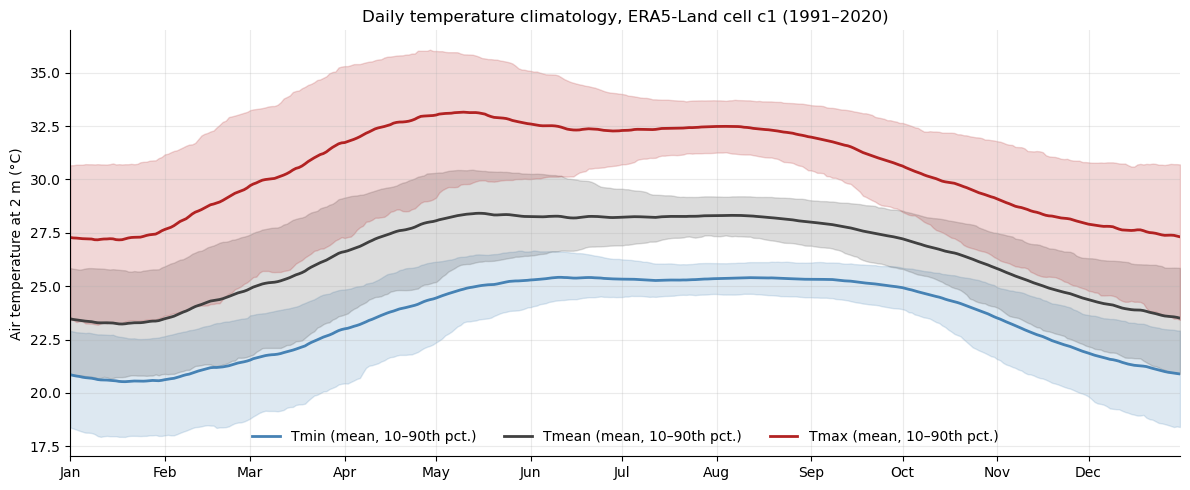

      Tmin mean  Tmin std  Tmean mean  Tmean std  Tmax mean  Tmax std
date                                                                 
Jan       20.56      0.81       23.25       0.88      27.18      1.10
Feb       21.10      0.77       24.21       0.91      28.69      1.15
Mar       22.05      0.81       25.53       0.94      30.52      1.05
Apr       23.76      0.64       27.44       0.79      32.55      0.96
May       25.03      0.64       28.41       0.87      33.10      1.16
Jun       25.38      0.49       28.20       0.67      32.32      0.90
Jul       25.29      0.35       28.27       0.49      32.40      0.70
Aug       25.39      0.36       28.25       0.43      32.35      0.56
Sep       25.21      0.41       27.68       0.53      31.45      0.69
Oct       24.35      0.49       26.61       0.70      29.87      1.08
Nov       22.66      0.77       25.03       0.75      28.38      0.97
Dec       21.29      0.89       23.89       0.87      27.62      0.95


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REF = slice('1991-01-01', '2020-12-31')
HALF = 15
TVARS = {'t2m_min_c': ('Tmin', 'steelblue'),
         't2m_c':     ('Tmean', '0.25'),
         't2m_max_c': ('Tmax', 'firebrick')}

ref_all = wx.loc[REF]
ref = ref_all[~((ref_all.index.month == 2) & (ref_all.index.day == 29))]
doy = (ref.index.dayofyear
       - (ref.index.is_leap_year & (ref.index.month > 2)).astype(int)).to_numpy()

def doy_climatology(values, doy, half=HALF):
    """Mean and 10/90th percentiles per day of year, pooled over a circular ±half-day window."""
    days = np.arange(1, 366)
    rows = []
    for d in days:
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)
        v = values[dist <= half]
        rows.append([v.mean(), *np.percentile(v, [10, 90])])
    return pd.DataFrame(rows, index=pd.Index(days, name='doy'),
                        columns=['mean', 'p10', 'p90'])

clim = {v: doy_climatology(ref[v].to_numpy(), doy) for v in TVARS}

# --- plot ---
x = pd.Timestamp('2001-01-01') + pd.to_timedelta(np.arange(365), unit='D')
fig, ax = plt.subplots(figsize=(12, 5))
for v, (label, color) in TVARS.items():
    c = clim[v]
    ax.fill_between(x, c['p10'], c['p90'], color=color, alpha=0.18)
    ax.plot(x, c['mean'], color=color, lw=2, label=f'{label} (mean, 10–90th pct.)')
ax.set_title('Daily temperature climatology, ERA5-Land cell c1 (1991–2020)')
ax.set_ylabel('Air temperature at 2 m (°C)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower center', ncol=3, frameon=False)
fig.tight_layout()
plt.show()

# --- monthly table: climatological mean + year-to-year std of monthly means ---
monthly_means = ref_all[list(TVARS)].resample('MS').mean()
table = monthly_means.groupby(monthly_means.index.month).agg(['mean', 'std'])
table.columns = [f'{TVARS[v][0]} {s}' for v, s in table.columns]
table.index = pd.to_datetime(table.index, format='%m').strftime('%b')
print(table.round(2))

# save for anomalies later
pd.concat(clim, axis=1).to_csv('clim_temperature_c1_1991-2020.csv')
table.to_csv('clim_temperature_c1_monthly_1991-2020.csv')

In [12]:
print((weather['t2m_c_c1'] - weather['t2m_c_c2']).abs().max(),
      (weather['precip_mm_c1'] - weather['precip_mm_c2']).abs().max())


0.0 0.0


      total median (mm)  total mean (mm)  total p10 (mm)  total p90 (mm)  \
date                                                                       
Jan                20.2             23.7             7.6            49.9   
Feb                12.5             17.0             4.2            34.0   
Mar                 9.9             13.4             2.0            24.2   
Apr                11.8             14.6             2.7            31.2   
May                26.6             31.7             9.4            63.2   
Jun                80.2             91.8            43.4           127.9   
Jul                45.9             52.4            27.9            77.6   
Aug                63.8             67.9            37.7            99.6   
Sep                93.9            103.6            57.6           130.0   
Oct                66.0             84.7            35.0           152.2   
Nov                26.8             34.8            12.5            59.7   
Dec         

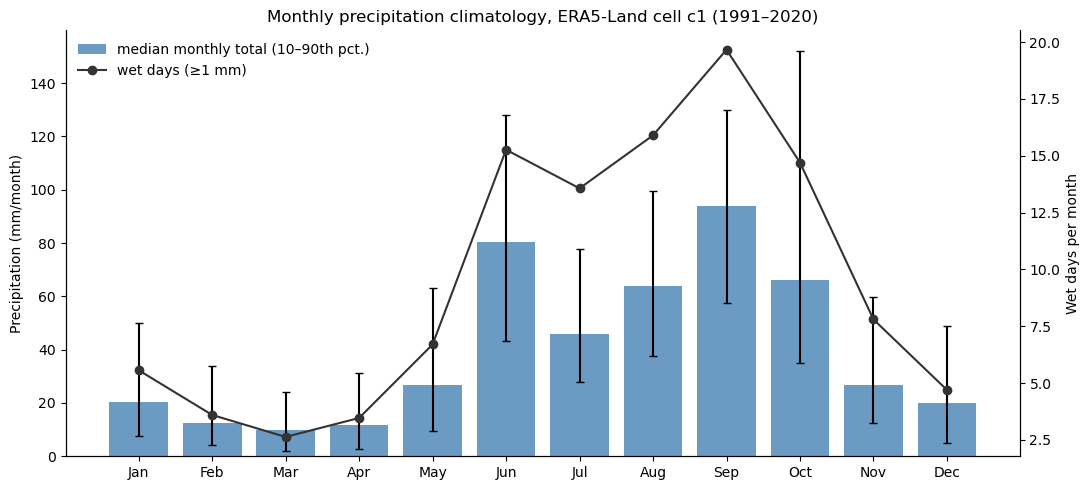

In [13]:
WET = 1.0  # mm; standard wet-day threshold, also filters ERA5's spurious drizzle
p = wx.loc[REF, 'precip_mm']

monthly_tot = p.resample('MS').sum()
wet_days    = (p >= WET).resample('MS').sum()
wet_vals    = p[p >= WET]

g_tot = monthly_tot.groupby(monthly_tot.index.month)
g_wet = wet_days.groupby(wet_days.index.month)
g_int = wet_vals.groupby(wet_vals.index.month)

ptab = pd.DataFrame({
    'total median (mm)':   g_tot.median(),
    'total mean (mm)':     g_tot.mean(),
    'total p10 (mm)':      g_tot.quantile(0.10),
    'total p90 (mm)':      g_tot.quantile(0.90),
    'wet days':            g_wet.mean(),
    'mm per wet day':      g_int.mean(),
    'p95 wet day (mm)':    g_int.quantile(0.95),
})
ptab.index = pd.to_datetime(ptab.index, format='%m').strftime('%b')
print(ptab.round(1))

annual = p.resample('YS').sum()
print(f"\nannual total 1991–2020: median {annual.median():.0f} mm, "
      f"mean {annual.mean():.0f} mm, range {annual.min():.0f} ({annual.idxmin():%Y}) "
      f"to {annual.max():.0f} ({annual.idxmax():%Y})")

# --- plot: median monthly total with 10–90th pct. whiskers + wet days ---
fig, ax = plt.subplots(figsize=(11, 5))
med = ptab['total median (mm)']
yerr = [med - ptab['total p10 (mm)'], ptab['total p90 (mm)'] - med]
ax.bar(ptab.index, med, color='steelblue', alpha=0.8, yerr=yerr, capsize=3,
       label='median monthly total (10–90th pct.)')
ax.set_ylabel('Precipitation (mm/month)')
ax2 = ax.twinx()
ax2.plot(ptab.index, ptab['wet days'], color='0.2', marker='o', label='wet days (≥1 mm)')
ax2.set_ylabel('Wet days per month')
ax.set_title('Monthly precipitation climatology, ERA5-Land cell c1 (1991–2020)')
ax.spines[['top']].set_visible(False); ax2.spines[['top']].set_visible(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', frameon=False)
fig.tight_layout()
plt.show()

ptab.to_csv('clim_precip_c1_monthly_1991-2020.csv')

In [14]:
chirps = (pd.read_csv('CHIRPS_daily_c1.csv', parse_dates=['date'])
            .set_index('date')['precip_chirps_mm'])

both = pd.concat({'era5l': wx['precip_mm'], 'chirps': chirps}, axis=1).loc['1991':'2020']
mon = both.resample('MS').sum()

# monthly anomalies (remove each month's climatology) -> do they agree on wet/dry months?
anom = mon - mon.groupby(mon.index.month).transform('mean')
ann = both.resample('YS').sum()

print(f"monthly totals   r = {mon.corr().iloc[0, 1]:.2f}")
print(f"monthly anomalies r = {anom.corr().iloc[0, 1]:.2f}")
print(f"annual totals    r = {ann.corr().iloc[0, 1]:.2f}")
print('\nIsidore, 21–24 Sep 2002:')
print(both.loc['2002-09-21':'2002-09-24'].round(1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ann.index.year, ann['era5l'], marker='o', label='ERA5-Land')
ax.plot(ann.index.year, ann['chirps'], marker='o', label='CHIRPS')
ax.set_ylabel('Annual precipitation (mm)')
ax.set_title('Annual precipitation, cell c1: ERA5-Land vs CHIRPS (1991–2020)')
ax.grid(alpha=0.25); ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'CHIRPS_daily_c1.csv'